# 影视作品网络

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False
from networkx.algorithms import bipartite
import json
from collections import defaultdict

In [3]:
import sys
sys.path.append("..")

# 数据处理

In [4]:
df_raw = pd.read_csv("../data/dwd_cast_works_rated_processed.csv")
df_raw['k_cast_id'] = df_raw['k_cast_id'].apply(lambda x: str(x))
df_raw

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg,main_cast
0,1017182,陈燕燕,女,10771202,演员,是,1,10771202,深闺疑云,电影,...,92,92.0,27.0,21542453,2034413,54,赵兰,m21542453,演员,"陈燕燕, 谢添"
1,1043845,刘志荣,男,10581318,演员,是,11,10581318,四大家族之龙虎兄弟,电影,...,2290,2290.0,134.0,21162685,2087739,75,NaN,m21162685,导演/演员/编剧,"郑则仕, 吕良伟, 利智, 曾江, 黄光亮"
2,1050373,茅瑛,女,10573512,演员,是,1,10573512,鬼娘子,电影,...,235,235.0,37.0,21147073,2100795,79,NaN,m21147073,演员,"茅瑛, 林威"
3,1124360,利智,女,10581318,演员,是,3,10581318,四大家族之龙虎兄弟,电影,...,2290,2290.0,134.0,21162685,2248769,94,NaN,m21162685,演员,"郑则仕, 吕良伟, 利智, 曾江, 黄光亮"
4,1314471,王挺,男,10531190,演员,是,1,10531190,惊天动地,电视剧,...,326,326.0,53.0,21062429,2628991,147,NaN,m21062429,导演/演员/编剧,"王挺, 李易祥, 王双宝"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283251,1354509,林泳淘,女,26984991,演员,否,999,26984991,婚姻合伙人,电视剧,...,1259,1259.0,85.0,53970031,2709067,608462,邓秀玉,m53970031,演员,"黄淑仪, 杨明, 高海宁, 黄德斌, 陆永"
283252,27496534,刘芊蒂,女,2337597,演员,是,2,2337597,操行零分,电影,...,211,211.0,38.0,4675243,54993117,608466,NaN,m4675243,演员,"何启南, 刘芊蒂"
283253,27565771,董亚春,女,2270516,导演,是,2,2270516,八月一日,电影,...,1123,1123.0,85.0,4541081,55131591,608467,NaN,m4541081,导演,"刘劲, 侯勇, 吕良伟"
283254,35415094,张可,女,7053738,演员,否,999,7053738,樱桃,电视剧,...,2003,2003.0,107.0,14107525,70830237,608472,NaN,m14107525,演员,"沈春阳, 宋小宝, 小沈阳, 赵本山"


# 方法

In [4]:
# 生成图
def get_G(df):
    G = nx.from_pandas_edgelist(
        df,
        source='k_cast_id',
        target='movie_id_m',
        edge_attr=True,
        create_using=nx.Graph()
    )
    return G

In [5]:
# 最大连通子图
def get_largest_connected_component(G):
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()

In [6]:
# 二分图，投影到电影节点
def get_movie_bip(G, cast_ids):
    return bipartite.projected_graph(G, G.nodes - cast_ids)

In [7]:
# 绘图
def draw_movie_net(G, k=None):
    pos = nx.spring_layout(G, k=k, seed=42)

    plt.figure(figsize=(10, 10))
    nx.draw_networkx(
        G,
        pos=pos,
        with_labels=False,
        node_size=1,
        edge_color="gainsboro",
        alpha=0.4,
    )
    plt.title("Movie Network")
    plt.axis('off')
    plt.show()
    print(G.number_of_nodes(), G.number_of_edges())

In [8]:
# 按评分提取数据
def get_lowest_rated_movie_casts(df, work_type="电影", ascending=True, top_n=100):
    df_type = df.loc[(df['k_type'] == work_type).copy()]
    df_type_simple = df_type[['movie_id_m', 'k_title',
                   'rating_num', 'k_rating_people']].drop_duplicates().reset_index(drop=True)
    df_type_n = df_type_simple.sort_values(by='rating_num', ascending=ascending).head(top_n)
    df_n = df_type_n[['movie_id_m']].merge(df,
                                            left_on='movie_id_m',
                                            right_on='movie_id_m',
                                            how='left')
    return df_n

In [9]:
# 作品筛选
def works_filter(df, work_type="电影", sort_by='rating_num', ascending=True, top_n=100, rating_people_min=0):
    df_type = df.loc[(df['k_type'] == work_type).copy()] if work_type else df
    df_type_simple = df_type[['movie_id_m', 'k_title',
                   'rating_num', 'k_rating_people']].drop_duplicates().reset_index(drop=True)
    df_type_n = df_type_simple[df_type_simple['k_rating_people'] >= rating_people_min].sort_values(by=sort_by, ascending=ascending).head(top_n)
    df_n = df_type_n[['movie_id_m']].merge(df_type,
                                            left_on='movie_id_m',
                                            right_on='movie_id_m',
                                            how='left')
    return df_n

In [10]:
# 度数为1的影人节点
def degree_1_cast_ids(G):
    degree_1_nodes = [node for node, degree in G.degree() if degree == 1]
    nodes_to_remove = [i for i in degree_1_nodes if 'm' not in str(i)]
    return nodes_to_remove

In [144]:
def get_chart_data(G,
                   df,
                   sub_pos=False,
                   work_type="电影",
                   degree_col='rating_num'):
    # 1. 数据预处理：转换类型并建立快速映射字典
    # 建立字典映射，避免在循环中反复查询 DataFrame，效率提升 100 倍以上
    # 只提取电影相关的属性列进行去重，避免 Index 冲突
    movie_cols = [
        'movie_id_m', 'k_title', 'rating_num', 'k_rating_people',
        'rating_index', 'k_type'
    ]
    # 过滤出 df 中存在的列，防止报错
    existing_movie_cols = [c for c in movie_cols if c in df.columns]
    movie_info = df[existing_movie_cols].drop_duplicates(
        'movie_id_m').set_index('movie_id_m').to_dict('index')

    # 演员信息去重
    cast_info = df.drop_duplicates('k_cast_id').set_index(
        'k_cast_id')['cast_name'].to_dict()

    nodes = list(G.nodes())
    movie_nodes = [n for n in nodes if 'm' in str(n)]
    cast_nodes = [n for n in nodes if 'm' not in str(n)]

    # 2. 布局计算
    if sub_pos:
        # pos = nx.kamada_kawai_layout(G)
        pos = nx.spring_layout(G)
    else:
        # 根据节点数量动态调整 k 值
        # k_val = 1.5 if len(nodes) >= 500 else 0.5
        # pos = nx.spring_layout(G, k=k_val, seed=42)
        pos = nx.spring_layout(G)
    # 3. 计算导演/演员节点的度数并归一化
    all_degrees = dict(G.degree())
    cast_degrees = {n: all_degrees[n] for n in cast_nodes}

    def normalize_degrees(deg_dict, target_min, target_max):
        if not deg_dict: return {}
        vals = np.array(list(deg_dict.values()))
        v_min, v_max = vals.min(), vals.max()
        denom = (v_max - v_min) if v_max != v_min else 1
        return {
            k: target_min + (target_max - target_min) * (v - v_min) / denom
            for k, v in deg_dict.items()
        }

    cast_degrees_norm = normalize_degrees(cast_degrees, 2, 7)

    # 4. 计算电影节点的度数/评分并归一化
    if degree_col:
        # 直接从预映射字典获取评分
        movie_degrees = {
            n: movie_info.get(n, {}).get(degree_col, 0)
            for n in movie_nodes
        }
    else:
        G_movie = bipartite.projected_graph(G, movie_nodes)
        movie_degrees = dict(G_movie.degree())

    movie_degrees_norm = normalize_degrees(movie_degrees, 2, 9)

    # 5. 构造节点数据
    nodes_data = []
    movie_count = 0

    # 影人类型
    cast_type = "/".join(df['k_role'].unique().tolist())

    for node in nodes:
        node_pos = pos[node]
        is_movie = 'm' in str(node)

        node_data = {
            'id': str(node),
            'x': round(float(node_pos[0]), 6),
            'y': round(float(node_pos[1]), 6)
        }

        if is_movie:
            info = movie_info.get(node, {})
            node_data.update({
                'category':
                work_type if work_type else info.get('k_type', '未知'),
                'title':
                info.get('k_title', '未知'),
                'degree':
                movie_degrees_norm.get(node, 2),
                'rating_num':
                info.get('rating_num', 0),
                'rating_people':
                info.get('k_rating_people', 0),
                'rating_index':
                info.get('rating_index', 0),
                'order':
                0 if work_type else (0 if info.get('k_type') == '电影' else 1),
                'is_work': True
            })
            movie_count += 1
        else:
            node_data.update({
                'category': cast_type,
                'title': cast_info.get(node, '未知演员'),
                'degree': cast_degrees_norm.get(node, 2),
                'order': 1 if work_type else 2,
                'is_work': False
            })

        nodes_data.append(node_data)

    # 6. 构造边与分类信息
    edges_data = [{
        'source': str(s),
        'target': str(t),
        'weight': 1
    } for s, t in G.edges()]
    cast_count = len(nodes) - movie_count

    if not work_type:
        categories = [{
            'name': '电影',
            'order': 0
        }, {
            'name': '电视剧',
            'order': 1
        }, {
            'name': cast_type,
            'order': 2
        }]
        subtitle = f"{movie_count}部影视作品, {cast_count}位影人"
    else:
        categories = [{
            'name': work_type,
            'order': 0
        }, {
            'name': cast_type,
            'order': 1
        }]
        subtitle = f"{movie_count}部{work_type}, {cast_count}位影人"

    return {
        'nodes': nodes_data,
        'edges': edges_data,
        'categories': categories,
        'subtitle': subtitle,
    }

In [145]:
# 生成电影二分图图表数据
def get_movie_bip_chart_data(G, df):
    nodes = G.nodes()
    # 二分图-电影
    movie_nodes = [n for n in nodes if 'm' in str(n)]
    G_movie = bipartite.weighted_projected_graph(G, movie_nodes)
    movie_degrees = dict(G_movie.degree())
    # 将movie_degrees归一到2-9的范围
    movie_degree_values = np.array(list(movie_degrees.values()))
    min_degree = movie_degree_values.min()
    max_degree = movie_degree_values.max()
    # 防止最大最小度数相等的情况
    if max_degree == min_degree:
        max_degree = df['rating_num'].max()
        min_degree = df['rating_num'].min()
        movie_degrees = {k: df[df['movie_id_m'] == k]['rating_num'].values[0] for k in movie_degrees.keys()}
    for key in movie_degrees:
        movie_degrees[key] = 2 + 7 * (movie_degrees[key] -
                                      min_degree) / (max_degree - min_degree)
    pos = nx.spring_layout(G_movie, k=3, scale=1, seed=412)
    nodes_data = []
    for node in movie_nodes:
        node_data = {}
        node_pos = pos[node]
        node_data['category'] = '电影'
        node_data['title'] = df[df['movie_id_m'] == node]['k_title'].values[0]
        node_data['degree'] = round(float(movie_degrees.get(node, 0)), 2)
        node_data['order'] = 0
        node_data['id'] = str(node)
        node_data['x'] = round(float(node_pos[0]), 6)
        node_data['y'] = round(float(node_pos[1]), 6)
        nodes_data.append(node_data)
    edges = G_movie.edges(data=True)
    edges_data = [{
        'source': str(s),
        'target': str(t),
        'weight': d['weight']
    } for s, t, d in edges]
    movie_num = len(movie_nodes)
    subtitle = f"{movie_num}部电影的关联关系"
    net_data = {
        'nodes': nodes_data,
        'edges': edges_data,
        'categories': [{
            'name': '电影',
            'order': 0
        }],
        'subtitle': subtitle,
    }
    return net_data

In [146]:
def get_chart_data_all(df, title_prefix, work_type="电影", degree_col='rating_num'):
    # 整图
    G_n = get_G(df)
    # 最大子图
    G_n_largest = get_largest_connected_component(G_n)
    movie_bip_data = get_movie_bip_chart_data(G_n_largest, df)
    # 去除度为1影人节点
    G_n_node_to_remove = degree_1_cast_ids(G_n)
    G_n_d2 = G_n.copy()
    G_n_d2.remove_nodes_from(G_n_node_to_remove)
    # 最大子图去除度为1影人节点
    G_n_largest_node_to_remove = degree_1_cast_ids(G_n_largest)
    G_n_d2_largest = G_n_largest.copy()
    G_n_d2_largest.remove_nodes_from(G_n_largest_node_to_remove)

    # 生成图表数据
    net_data = get_chart_data(G_n, df, work_type=work_type, degree_col=degree_col)
    net_data['title'] = title_prefix + "-全量数据"
    net_data_largest = get_chart_data(G_n_largest, df, work_type=work_type, degree_col=degree_col)
    net_data_largest['title'] = title_prefix + "-最大连通子图"
    net_data_d2 = get_chart_data(G_n_d2, df, sub_pos=True, work_type=work_type, degree_col=degree_col)
    net_data_d2['title'] = title_prefix + "-去除度为1的影人节点"
    net_data_d2_largest = get_chart_data(G_n_d2_largest, df, sub_pos=True, work_type=work_type, degree_col=degree_col)
    net_data_d2_largest['title'] = title_prefix + "-最大连通子图去除度为1的影人节点"
    net_data = {
        "net_data": net_data,
        "net_data_largest": net_data_largest,
        "net_data_d2": net_data_d2,
        "net_data_d2_largest": net_data_d2_largest,
        "movie_bip_data": movie_bip_data
    }
    return net_data

In [142]:
top_desc = """
主流的电影研究往往集中在高分经典上——演员的奖项、导演的稳定创作力、以及票房表现等传统指标。
但我在想，既然好片能养出“黄金合作班底”，那这些经典佳作之间，是否也隐藏着某种合作网络？
于是，我从豆瓣中选取了
[向右R][向右R]评分人数超过10万人且评分最高的200部电影，
这批作品的分数高得离谱：最低都在 7.6分以上，最顶尖的甚至稳居影史榜单多年不动。
围绕这 200 部影片的 2700 位导演与主要演员（影人），我以“影人—电影”为连边关系，构建了一个无向图模型，进而得到了这批高分电影的合作关系网络，也就是下面的四张图。
[一R]图 1：
高分电影关系网（完整网络）
包含全部 200 部高分电影及其导演与主演。
可以看到整体结构相对庞大，包含多个连通子图。
有些子图像散落在影史角落的“小宇宙”，彼此之间并不直接关联。
如果你眼尖，说不定还能在图里找出某些你熟悉的组合。
[二R]图 2：
高分电影关系网（最大连通子图）
当我们剔除那些完全孤立的子图后，剩下的最大连通子图变得更加紧密，该子图包含175部电影及2574位影人。
不过仍然可以看到不少 “度为 1” 的影人节点——这意味着他们只在这 200 部电影中参与了一部作品。
为了让合作模式更清晰，我进一步剔除了这些度为 1 的节点，得到下方更集中的网络结构。
[三R]图 3：
高分电影关系网（去除度为1影人），此时剩余545位影人，而电影仍为200部。
可以看到部分电影节点变成孤立点，说明它们的主创人员并未与其他高分电影形成交叉合作。
但整体结构的形态开始显现，影史中那些频繁合作的黄金阵容也开始浮出水面。
[四R]图 4：
高分电影关系网（最大连通子图 + 去除度为1影人）
这是整个结构最紧凑、也最具“合作意义”的部分，此时剩余175部电影及539位影人。
影人之间的联系在这里最为密切，能看出哪些导演常与固定班底合作，以及哪些演员频繁在高质量项目中相遇。
研究这些高分电影的合作网络，能从另一种角度理解“经典是如何诞生的”：
不仅是导演与演员的个人实力，更是长期合作、默契搭档，以及稳定可靠的创作关系网在背后支撑。
当然，他们并不一定只拍佳作，高分电影只是他们职业轨迹上的亮眼部分。但正是这些高分作品，构成了他们在电影史中的共同坐标。
[向右R][向右R]特别声明：
数据来源于公开的网络数据，旨在探索电影合作网络的结构特征，难免存在遗漏或错误，内容仅限学习与研究使用。
#数据可视化 #经典电影推荐 #与电影对视120次 
"""

# main

In [85]:
df_raw 

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg
0,1017182,陈燕燕,女,10771202,演员,是,1,10771202,深闺疑云,电影,...,7.8,92,92.0,27.0,21542453,2034413,54,赵兰,m21542453,演员
1,1043845,刘志荣,男,10581318,演员,是,11,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2087739,75,NaN,m21162685,导演/演员
2,1050373,茅瑛,女,10573512,演员,是,1,10573512,鬼娘子,电影,...,5.8,235,235.0,37.0,21147073,2100795,79,NaN,m21147073,演员
3,1124360,利智,女,10581318,演员,是,3,10581318,四大家族之龙虎兄弟,电影,...,7.8,2290,2290.0,134.0,21162685,2248769,94,NaN,m21162685,演员
4,1314471,王挺,男,10531190,演员,是,1,10531190,惊天动地,电视剧,...,8.5,326,326.0,53.0,21062429,2628991,147,NaN,m21062429,导演/演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258254,1354509,林泳淘,女,26984991,演员,否,999,26984991,婚姻合伙人,电视剧,...,5.8,1259,1259.0,85.0,53970031,2709067,608462,邓秀玉,m53970031,演员
258255,27496534,刘芊蒂,女,2337597,演员,是,2,2337597,操行零分,电影,...,7.0,211,211.0,38.0,4675243,54993117,608466,NaN,m4675243,演员
258256,27565771,董亚春,女,2270516,导演,是,2,2270516,八月一日,电影,...,6.4,1123,1123.0,85.0,4541081,55131591,608467,NaN,m4541081,导演
258257,35415094,张可,女,7053738,演员,否,999,7053738,樱桃,电视剧,...,5.7,2003,2003.0,107.0,14107525,70830237,608472,NaN,m14107525,演员


In [86]:
work_type = '电视剧'
work_type_value = 'movie' if work_type == '电影' else 'tv'
sort_by = 'rating_num'
ascending = False
asc_value = 'min' if ascending else 'max'
title_value = '低分' if ascending else '高分'
top_n = 200
rating_people_min = 30000
df_filtered = works_filter(df_raw, work_type=work_type, sort_by=sort_by, ascending=ascending, top_n=top_n, rating_people_min=rating_people_min)
df_filtered

,movie_id_m,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,...,is_rating,rating_num,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,cast_role_agg
0,m2883637,27483006,韩再芬,女,1441794,演员,否,999,1441794,走向共和,...,有评分,9.7,73275,73275.0,843.0,2883637,54966061,27685,沈玉英,导演/演员
1,m2883637,30414323,洪宗义,男,1441794,演员,否,999,1441794,走向共和,...,有评分,9.7,73275,73275.0,843.0,2883637,60828695,35469,方伯谦,演员
2,m2883637,27483118,马仑,男,1441794,演员,否,999,1441794,走向共和,...,有评分,9.7,73275,73275.0,843.0,2883637,54966285,58547,段祺瑞,演员
3,m2883637,27562254,刘伟明,男,1441794,演员,否,999,1441794,走向共和,...,有评分,9.7,73275,73275.0,843.0,2883637,55124557,65510,张謇,导演/演员
4,m2883637,27482432,赵立新,男,1441794,演员,否,999,1441794,走向共和,...,有评分,9.7,73275,73275.0,843.0,2883637,54964913,71733,罗文,演员
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8446,m69559601,1381885,黄馨瑶,女,34779776,演员,否,999,34779776,苍兰诀,...,有评分,8.1,650830,650830.0,2296.0,69559601,2763819,455890,三生,演员
8447,m69559601,27575553,李一桐,女,34779776,演员,是,6,34779776,苍兰诀,...,有评分,8.1,650830,650830.0,2296.0,69559601,55151155,488613,司命,演员
8448,m69559601,35065662,程梓,女,34779776,演员,否,999,34779776,苍兰诀,...,有评分,8.1,650830,650830.0,2296.0,69559601,70131373,508530,蝶衣,演员
8449,m69559601,27573708,王鹤棣,男,34779776,演员,是,2,34779776,苍兰诀,...,有评分,8.1,650830,650830.0,2296.0,69559601,55147465,516353,东方青苍,演员


In [87]:
df_info = df_filtered[['k_movie_id', 'k_title', 'rating_num', 'k_movie_year', 'k_rating_people', 'k_type']].drop_duplicates().sort_values(by='rating_num', ascending=ascending).reset_index(drop=True)
df_info['k_movie_id'] = df_info['k_movie_id'].apply(lambda x: str(x))
df_info.to_json(f'json_data/works_info_{work_type_value}_{sort_by}_{asc_value}_{top_n}_{rating_people_min}.json', orient='records', force_ascii=False, indent=4)
df_info

,k_movie_id,k_title,rating_num,k_movie_year,k_rating_people,k_type
0,2883637,走向共和,9.7,2003,73275.0,电视剧
1,4420051,大明王朝1566,9.7,2007,145676.0,电视剧
2,3729669,红楼梦,9.7,1987,168190.0,电视剧
3,53207743,毛骗 终结篇,9.7,2015,120257.0,电视剧
4,7765479,武林外传,9.6,2006,400757.0,电视剧
...,...,...,...,...,...,...
195,69726703,我才不要和你做朋友呢,8.2,2020,159891.0,电视剧
196,53861129,无证之罪,8.1,2017,228734.0,电视剧
197,71451761,尘封十三载,8.1,2023,142058.0,电视剧
198,53532477,风起陇西,8.1,2022,101385.0,电视剧


In [88]:
net_data = get_chart_data_all(df_filtered, title_prefix=f"{title_value}{work_type}关系网络", work_type=work_type)
# 保存处理后的数据
with open(f'json_data/net_data_{work_type_value}_{sort_by}_{asc_value}_{top_n}_{rating_people_min}.json', 'w', encoding='utf-8') as f:
    json.dump(net_data, f, ensure_ascii=False, indent=4)

KeyboardInterrupt: 

In [ ]:
df_raw

# 年代专题


## 2025年

In [ ]:
movie_year = 2025
df_year = df_raw[df_raw['k_movie_year'] == movie_year]
df_year

In [ ]:
# 作品数量
works_num = df_year['movie_id_m'].nunique()
movie_num = df_year[df_year['k_type'] == '电影']['movie_id_m'].nunique()
tv_num = df_year[df_year['k_type'] == '电视剧']['movie_id_m'].nunique()
works_num, movie_num, tv_num

In [ ]:
net_data_year = get_chart_data_all(df_year, title_prefix=f"{movie_year}年华语影视关系网络", work_type=None)
# 保存处理后的数据
with open(f'json_data/net_data_{movie_year}.json', 'w', encoding='utf-8') as f:
    json.dump(net_data_year, f, ensure_ascii=False, indent=4)

In [ ]:
# 生成一段 df_year 数据描述
description_year = f"""2025年华语影视作品关系网络包含 {works_num} 部影视作品，其中电影 {movie_num} 部，电视剧 {tv_num} 部。围绕这些作品的导演与主要演员，共有 {len(df_year['k_cast_id'].unique())} 位，他们共同构成了这个复杂而丰富的影视关系网络。"""

description_year

# 特定范围

In [ ]:
k_cast_id = "55130387"

In [ ]:
# 包含k_cast_id的所有movie_id_m，含这些movie_id_m的所有记录
df_cast_movies = df_raw[df_raw['k_cast_id'] == k_cast_id][['movie_id_m']].drop_duplicates()
df_cast_related = df_raw.merge(df_cast_movies,
                              left_on='movie_id_m',
                              right_on='movie_id_m',
                              how='inner')
df_cast_related

In [ ]:
df_cast_related['movie_id_m'].nunique()

In [ ]:
df_cast_related['k_title'].unique()

In [127]:
# specific_works = pd.read_csv("youyin_cast_works.csv")
specific_works = pd.read_csv("../data/zwyg_rated_processed.csv")
specific_works

,cast_id,cast_name,gender,movie_id,k_role,is_main_cast,index,id,k_title,k_type,...,rating_people,k_rating_people,rating_index,k_movie_id,k_cast_id,uid,portray,movie_id_m,cast_role_agg,main_cast
0,27559561,张东升,男,26665065,演员,是,42,26665065,琅琊榜之风起长林,电视剧,...,210088,210088,1328,53330179,55119171,2,晋尚书,m53330179,演员,"黄晓明, 刘昊然, 佟丽娅, 张慧雯, 梅婷"
1,27484015,尚铁龙,男,35033654,演员,是,29,35033654,山海情,电视剧,...,481571,481571,2105,70067357,54968079,4,李运胜,m70067357,演员,"黄轩, 张嘉益, 闫妮, 黄觉, 姚晨"
2,27484015,尚铁龙,男,33442331,演员,是,14,33442331,我是余欢水,电视剧,...,324953,324953,1540,66884711,54968079,5,余父,m66884711,演员,"郭京飞, 苗苗, 高露, 岳旸, 高叶"
3,27547234,陈昊宇,女,36189205,演员,是,6,36189205,凡人歌,电视剧,...,77700,77700,773,72378459,55094517,6,谢美蓝,m72378459,演员,"殷桃, 王骁, 章若楠, 秦俊杰, 张哲华"
4,27558329,杨晓丹,女,34792295,演员,是,61,34792295,乔家的儿女,电视剧,...,235622,235622,1347,69584639,55116707,7,孙姨,m69584639,演员,"白宇, 宋祖儿, 毛晓彤, 张晚意, 周翊然"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2083,30426384,李至强,男,27088993,演员,否,999,27088993,都挺好,电视剧,...,394106,394106,1742,54178035,60852817,2693,正诚审计主任,m54178035,演员,"姚晨, 倪大红, 郭京飞, 杨祐宁, 李念"
2084,30426384,李至强,男,26797690,演员,否,999,26797690,大江大河,电视剧,...,260126,260126,1513,53595429,60852817,2694,李厂长,m53595429,演员,"王凯, 杨烁, 杨烁, 董子健, 童瑶"
2085,30426384,李至强,男,26759908,演员,否,999,26759908,清平乐,电视剧,...,173456,173456,1054,53519865,60852817,2695,程琳,m53519865,演员,"王凯, 江疏影, 任敏, 杨玏, 边程"
2086,35024791,许潇晗,女,34792295,演员,是,44,34792295,乔家的儿女,电视剧,...,235622,235622,1347,69584639,70049631,2696,柳小萌,m69584639,演员,"白宇, 宋祖儿, 毛晓彤, 张晚意, 周翊然"


In [147]:
net_data_specific = get_chart_data_all(specific_works, title_prefix=f"正午阳光作品宇宙", work_type=None, degree_col="rating_index")
# 保存处理后的数据
with open(f'json_data/net_data_specific.json', 'w', encoding='utf-8') as f:
    json.dump(net_data_specific, f, ensure_ascii=False, indent=4)

# 作品展示数据

In [126]:
cast_sorted = specific_works[(specific_works['is_main_cast'] == '是') & (specific_works['k_role'] == '演员')].sort_values(by=['k_movie_id', 'index'], ascending=[True, True])

# 2. 分组聚合：取每个电影前5名，用逗号连接
main_cast_series = cast_sorted.groupby('k_movie_id')['cast_name'] \
    .apply(lambda x: ', '.join(x.head(5)))

# 3. 映射回原表：使用 map 匹配 k_movie_id，确保索引正确
specific_works['main_cast'] = specific_works['k_movie_id'].map(main_cast_series)
df_info_specific = specific_works[['k_movie_id', 'k_title', 'rating_num', 'k_movie_year', 'k_rating_people', 'k_type', 'main_cast']].drop_duplicates().sort_values(by='k_movie_year', ascending=True).reset_index(drop=True)
df_info_specific['k_movie_id'] = df_info_specific['k_movie_id'].apply(lambda x: str(x))
df_info_specific.to_json(f'json_data/works_info_specific.json', orient='records', force_ascii=False, indent=4)
df_info_specific

,k_movie_id,k_title,rating_num,k_movie_year,k_rating_people,k_type,main_cast
0,51740629,温州两家人,7.8,2015,7118,电视剧,"郭涛, 任程伟, 袁咏仪, 陈丽娜, 刘奕君"
1,52176963,他来了，请闭眼,6.7,2015,74395,电视剧,"霍建华, 马思纯, 张鲁一, 王凯, 尹正"
2,51509745,琅琊榜,9.4,2015,919060,电视剧,"胡歌, 刘涛, 王凯, 陈龙, 黄维德"
3,51989473,伪装者,8.6,2015,382758,电视剧,"胡歌, 靳东, 刘敏涛, 王凯, 宋轶"
4,52597919,鬼吹灯之精绝古城,7.9,2016,274802,电视剧,"靳东, 陈乔恩, 赵达, 岳旸, 王永泉"
5,52690323,如果蜗牛有爱情,7.2,2016,105271,电视剧,"王凯, 王子文, 徐悦, 于恒, 赵圆瑗"
6,52860233,欢乐颂,7.5,2016,353514,电视剧,"刘涛, 蒋欣, 王子文, 杨紫, 乔欣"
7,53487195,欢乐颂2,5.4,2017,154450,电视剧,"刘涛, 蒋欣, 王子文, 杨紫, 乔欣"
8,53367499,外科风云,7.3,2017,94754,电视剧,"靳东, 白百何, 李佳航, 马少骅, 蓝盈莹"
9,53330179,琅琊榜之风起长林,8.4,2017,210088,电视剧,"黄晓明, 刘昊然, 佟丽娅, 张慧雯, 梅婷"


# 特定作品

In [ ]:
movie_id_m = "m9776509"

In [ ]:
# 指定movie_id_m的所有k_cast_id
df_movie_casts = df_raw[df_raw['movie_id_m'] == movie_id_m][['k_cast_id']].drop_duplicates()
# 这些k_cast_id的所有movie_id_m
df_casts_movies = df_raw[df_raw['k_cast_id'].isin(df_movie_casts['k_cast_id'])][['movie_id_m']].drop_duplicates()
# 这些movie_id_m的所有记录
df_movie_related = df_raw.merge(df_casts_movies,
                                left_on='movie_id_m',
                                right_on='movie_id_m',
                                how='inner')
df_movie_related['k_title'].unique()

In [ ]:
df_raw

# 数据统计

In [ ]:
top_n = 200
df_movie_top_n = get_lowest_rated_movie_casts(df_raw,
                                              ascending=False,
                                              top_n=top_n)
df_movie_top_n

In [ ]:
df_movie_top_n_asc = get_lowest_rated_movie_casts(df_raw,
                                              ascending=True,
                                              top_n=top_n)
df_movie_top_n_asc

In [172]:
# 计数
def get_df_stats(df):
    # 作品数量
    works_count = df['movie_id_m'].nunique()
    # 导演数量
    director_count = df[df['k_role'] == '导演']['k_cast_id'].nunique()
    # 编剧数量
    writer_count = df[df['k_role'] == '编剧']['k_cast_id'].nunique()
    # 演员数量
    actor_count = df[df['k_role'] == '演员']['k_cast_id'].nunique()
    # 影人数量
    cast_count = df['k_cast_id'].nunique()
    # 最高分
    rating_max = df['rating_num'].max()
    # 最低分
    rating_min = df['rating_num'].min()
    # 平均分
    rating_mean = df['rating_num'].mean()
    # 总评分人次
    rating_people_num = df[['movie_id_m', 'k_rating_people'
                            ]].drop_duplicates()['k_rating_people'].sum()
    rating_people_num = int(rating_people_num)
    return {
        'works_count': works_count,
        'director_count': director_count,
        'writer_count': writer_count,
        'actor_count': actor_count,
        'cast_count': cast_count,
        'rating_max': rating_max,
        'rating_min': rating_min,
        'rating_mean': round(rating_mean, 2),
        'rating_people_num': rating_people_num
    }

In [173]:
# 图指标
def get_graph_metrics(G, df, is_bipartite=False):
    metrics = {}
    # 度
    degrees = dict(G.degree())
    # 节点数
    metrics['num_nodes'] = G.number_of_nodes()
    # 边数
    metrics['num_edges'] = G.number_of_edges()
    # 介数中心性最大值节点
    betweenness = nx.betweenness_centrality(G)

    if is_bipartite:
        # 最大度
        max_degree = max(degrees.values())
        metrics['max_degree'] = max_degree
        if max_degree > 1:
            # 最大度节点
            max_degree_node = [n for n in G.nodes() if degrees[n] == max_degree]
            # metrics['max_degree_node'] = max_degree_node
            # 最大度节点名称
            max_degree_node_names = []
            for n in max_degree_node:
                if 'm' in str(n):
                    name = df[df['movie_id_m'] == n]['k_title'].unique().tolist()
                else:
                    name = df[df['k_cast_id'] == n]['cast_name'].unique().tolist()
                max_degree_node_names.extend(name)
            metrics['max_degree_node_names'] = ",".join(max_degree_node_names)
        # 最大介数中心性
        max_betweenness = max(betweenness.values())
        metrics['max_betweenness'] = round(max_betweenness, 6)
        if max_betweenness > 0:
            # 最大介数中心性节点
            max_betweenness_node = [n for n in G.nodes() if betweenness[n] == max_betweenness]
            # metrics['max_betweenness_node'] = max_betweenness_node
            # 最大介数中心性节点名称
            max_betweenness_node_names = []
            for n in max_betweenness_node:
                if 'm' in str(n):
                    name = df[df['movie_id_m'] == n]['k_title'].unique().tolist()
                else:
                    name = df[df['k_cast_id'] == n]['cast_name'].unique().tolist()
                max_betweenness_node_names.extend(name)
            metrics['max_betweenness_node_names'] = ",".join(max_betweenness_node_names)
    else:
        # 影人节点
        cast_nodes = [n for n in G.nodes() if 'm' not in str(n)]
        # 影人节点数
        metrics['num_cast_nodes'] = len(cast_nodes)
        # 影人节点最大度
        max_cast_degree = max([degrees[n] for n in cast_nodes])
        metrics['max_cast_degree'] = max_cast_degree
        if max_cast_degree > 1:
            # 最大度影人节点
            max_cast_degree_node = [n for n in cast_nodes if degrees[n] == max_cast_degree]
            # 最大度影人节点名称
            max_cast_degree_node_names = df[df['k_cast_id'].isin(max_cast_degree_node)]['cast_name'].unique().tolist()
            # metrics['max_cast_degree_node'] = max_cast_degree_node
            metrics['max_cast_degree_node_names'] = ",".join(max_cast_degree_node_names)
        # 介数中心性最大值影人节点
        max_cast_betweenness = max([betweenness[n] for n in cast_nodes])
        metrics['max_cast_betweenness'] = round(max_cast_betweenness, 6)
        if max_cast_betweenness > 0:
            # 最大介数中心性影人节点
            max_cast_betweenness_node = [n for n in cast_nodes if betweenness[n] == max_cast_betweenness]
            # 最大介数中心性影人节点名称
            max_cast_betweenness_node_names = df[df['k_cast_id'].isin(max_cast_betweenness_node)]['cast_name'].unique().tolist()
            # metrics['max_cast_betweenness_node'] = max_cast_betweenness_node
            metrics['max_cast_betweenness_node_names'] = ",".join(max_cast_betweenness_node_names)

        # 电影节点
        movie_nodes = [n for n in G.nodes() if 'm' in str(n)]
        # 电影节点数
        metrics['num_movie_nodes'] = len(movie_nodes)
        # 电影节点最大度
        max_movie_degree = max([degrees[n] for n in movie_nodes])
        metrics['max_movie_degree'] = max_movie_degree
        if max_movie_degree > 1:
            # 最大度电影节点
            max_movie_degree_node = [n for n in movie_nodes if degrees[n] == max_movie_degree]
            # 最大度电影节点名称
            max_movie_degree_node_names = df[df['movie_id_m'].isin(max_movie_degree_node)]['k_title'].unique().tolist()
            # metrics['max_movie_degree_node'] = max_movie_degree_node
            metrics['max_movie_degree_node_names'] = ",".join(max_movie_degree_node_names)
        # 最大介数中心性电影节点
        max_movie_betweenness = max([betweenness[n] for n in movie_nodes])
        metrics['max_movie_betweenness'] = round(max_movie_betweenness, 6)
        if max_movie_betweenness > 0:
            # 最大介数中心性电影节点
            max_movie_betweenness_node = [n for n in movie_nodes if betweenness[n] == max_movie_betweenness]
            # 最大介数中心性电影节点名称
            max_movie_betweenness_node_names = df[df['movie_id_m'].isin(max_movie_betweenness_node)]['k_title'].unique().tolist()
            # metrics['max_movie_betweenness_node'] = max_movie_betweenness_node
            metrics['max_movie_betweenness_node_names'] = ",".join(max_movie_betweenness_node_names)

    # 密度
    metrics['density'] = round(nx.density(G), 6)
    # 平均聚类系数
    # metrics['average_clustering'] = nx.average_clustering(G)
    # 是否连通图
    metrics['is_connected'] = "是" if nx.is_connected(G) else "否"
    # 直径（仅适用于连通图）
    if nx.is_connected(G):
        metrics['diameter'] = nx.diameter(G)
    else:
        # metrics['diameter'] = None
        # 子图数量
        metrics['num_connected_components'] = nx.number_connected_components(G)
        # 最大子图
        largest_cc = max(nx.connected_components(G), key=len)
        G_largest = G.subgraph(largest_cc).copy()
        metrics['largest_cc_num_nodes'] = G_largest.number_of_nodes()
        metrics['largest_cc_num_nodes_ratio'] = f"{round(G_largest.number_of_nodes() / G.number_of_nodes() * 100, 2)}%"
        metrics['largest_cc_num_edges'] = G_largest.number_of_edges()
        metrics['largest_cc_num_edges_ratio'] = f"{round(G_largest.number_of_edges() / G.number_of_edges() * 100, 2)}%"

    return metrics

In [174]:
# main
def movie_net_stats(df):
    G = get_G(df)
    stats = {}
    stats['df_stats'] = get_df_stats(df)
    stats['graph_metrics'] = get_graph_metrics(G, df)
    if stats['graph_metrics']['is_connected'] == "否":
        largest_cc = max(nx.connected_components(G), key=len)
        stats['largest_connected_component'] = get_graph_metrics(G.subgraph(largest_cc).copy(), df)
    # 二分图-电影
    movie_nodes = [n for n in G.nodes() if 'm' in str(n)]
    G_movie = bipartite.projected_graph(G, movie_nodes)
    stats['movie_bipartite_graph_metrics'] = get_graph_metrics(G_movie, df, is_bipartite=True)
    # 最大连通子图二分图-电影
    if not nx.is_connected(G_movie):
        largest_cc = max(nx.connected_components(G_movie), key=len)
        stats['movie_bipartite_largest_connected_component'] = get_graph_metrics(G_movie.subgraph(largest_cc).copy(), df, is_bipartite=True)
    # 二分图-影人
    cast_nodes = [n for n in G.nodes() if 'm' not in str(n)]
    G_cast = bipartite.projected_graph(G, cast_nodes)
    stats['cast_bipartite_graph_metrics'] = get_graph_metrics(G_cast, df, is_bipartite=True)
    # 最大连通子图二分图-影人
    if not nx.is_connected(G_cast):
        largest_cc = max(nx.connected_components(G_cast), key=len)
        stats['cast_bipartite_largest_connected_component'] = get_graph_metrics(G_cast.subgraph(largest_cc).copy(), df, is_bipartite=True)
    return stats


In [ ]:
year_stats = movie_net_stats(df_year)
year_stats

In [ ]:
top_stats = movie_net_stats(df_movie_top_n)

In [ ]:
top_stats_asc = movie_net_stats(df_movie_top_n_asc)

In [190]:
# 中英文对照字典
key_to_chinese = {
    'works_count': '作品数量',
    'director_count': '导演数量',
    'writer_count': '编剧数量',
    'actor_count': '演员数量',
    'cast_count': '影人数量',
    'rating_max': '最高评分',
    'rating_min': '最低评分',
    'rating_mean': '平均评分',
    'rating_people_num': '评分总人次',
    'num_nodes': '节点数',
    'num_edges': '边数',
    'max_degree': '最大度',
    'max_degree_node': '最大度节点',
    'max_degree_node_names': '最大度节点名称',
    'max_betweenness': '最大介数中心性',
    'max_betweenness_node': '最大介数中心性节点',
    'max_betweenness_node_names': '最大介数中心性节点名称',
    'num_cast_nodes': '影人节点数',
    'max_cast_degree': '影人最大度',
    'max_cast_degree_node': '影人最大度节点',
    'max_cast_degree_node_names': '影人最大度节点名称',
    'max_cast_betweenness': '影人最大介数中心性',
    'max_cast_betweenness_node': '影人最大介数中心性节点',
    'max_cast_betweenness_node_names': '影人最大介数中心性节点名称',
    'num_movie_nodes': '作品节点数',
    'max_movie_degree': '作品最大度',
    'max_movie_degree_node': '作品最大度节点',
    'max_movie_degree_node_names': '作品最大度节点名称',
    'max_movie_betweenness': '作品最大介数中心性',
    'max_movie_betweenness_node': '作品最大介数中心性节点',
    'max_movie_betweenness_node_names': '作品最大介数中心性节点名称',
    'density': '密度',
    'average_clustering': '平均聚类系数',
    'is_connected': '是否连通',
    'diameter': '直径',
    'num_connected_components': '连通子图数量',
    'largest_cc_num_nodes': '最大连通子图节点数',
    'largest_cc_num_nodes_ratio': '最大连通子图节点比例',
    'largest_cc_num_edges': '最大连通子图边数',
    'largest_cc_num_edges_ratio': '最大连通子图边比例'
}
# 指标说明
metric_description = {
    'works_count': '电影/电视剧数量',
    'director_count': '导演总数',
    'writer_count': '编剧总数',
    'actor_count': '演员总数',
    'cast_count': '统计中涉及的影人总数',
    'rating_max': '所有作品中的最高评分值',
    'rating_min': '所有作品中的最低评分值',
    'rating_mean': '所有作品评分的平均值',
    'rating_people_num': '所有作品评分人次的总和',
    'num_nodes': '网络中节点的总数量',
    'num_edges': '网络中边的总数量',
    'max_degree': '节点中最大的度值（度：节点连接的边数，反映直接影响力）',
    'max_degree_node': '具有最大度值的节点ID',
    'max_degree_node_names': '具有最大度值的节点名称',
    'max_betweenness': '节点中最大的介数中心性值（介数中心性：衡量节点作为桥梁的重要性）',
    'max_betweenness_node': '具有最大介数中心性的节点ID',
    'max_betweenness_node_names': '具有最大介数中心性的节点名称',
    'num_cast_nodes': '影人类型节点的数量',
    'max_cast_degree': '影人节点中最大的度值（度：节点连接的边数，这里是影人参与的作品数量）',
    'max_cast_degree_node': '具有最大度值的影人节点ID',
    'max_cast_degree_node_names': '具有最大度值的影人姓名',
    'max_cast_betweenness': '影人节点中最大的介数中心性值（介数中心性：衡量节点作为桥梁的重要性）',
    'max_cast_betweenness_node': '具有最大介数中心性的影人节点ID',
    'max_cast_betweenness_node_names': '具有最大介数中心性的影人姓名',
    'num_movie_nodes': '作品类型节点的数量',
    'max_movie_degree': '作品节点中最大的度值（度：节点连接的边数，反映合作影人数量）',
    'max_movie_degree_node': '具有最大度值的作品节点ID',
    'max_movie_degree_node_names': '具有最大度值的作品名称',
    'max_movie_betweenness': '作品节点中最大的介数中心性值（介数中心性：衡量节点在网络连通中的关键程度）',
    'max_movie_betweenness_node': '具有最大介数中心性的作品节点ID',
    'max_movie_betweenness_node_names': '具有最大介数中心性的作品名称',
    'density': '网络的密度，表示实际边数与可能最大边数的比值',
    'average_clustering': '网络中所有节点的聚类系数的平均值',
    'is_connected': '判断网络是否连通（即任意两个节点间都存在路径）',
    'diameter': '网络的直径，即所有节点对之间最短路径的最大长度',
    'num_connected_components': '网络中连通子图的数量',
    'largest_cc_num_nodes': '网络中最大连通子图包含的节点数量',
    'largest_cc_num_nodes_ratio': '最大连通子图节点数占网络总节点数的比例',
    'largest_cc_num_edges': '网络中最大连通子图包含的边数量',
    'largest_cc_num_edges_ratio': '最大连通子图边数占网络总边数的比例'
}
stats_parts_dict = {
    'df_stats': '原始数据统计',
    'graph_metrics': '整体网络图指标',
    'largest_connected_component': '最大连通子图指标',
    'movie_bipartite_graph_metrics': '作品二分图指标',
    'movie_bipartite_largest_connected_component': '作品二分图最大连通子图指标',
    'cast_bipartite_graph_metrics': '影人二分图指标',
    'cast_bipartite_largest_connected_component': '影人二分图最大连通子图指标'
}

ststs_index_dict = {
    'key_to_chinese': key_to_chinese,
    'metric_description': metric_description,
    'stats_parts_dict': stats_parts_dict
}
with open(f'json_data/net_stats_index.json', 'w', encoding='utf-8') as f:
    json.dump(ststs_index_dict, f, ensure_ascii=False, indent=4)

In [152]:
def stats_to_excel(stats, filename):
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for part_key, part_name in stats_parts_dict.items():
            if part_key in stats:
                part_stats = stats[part_key]
                df_part = pd.DataFrame({
                    '指标':
                    [key_to_chinese.get(k, k) for k in part_stats.keys()],
                    '值':
                    list(part_stats.values()),
                    '说明':
                    [metric_description.get(k, '') for k in part_stats.keys()]
                })
                df_part.to_excel(writer, sheet_name=part_name, index=False)
        

In [175]:
specific_stats = movie_net_stats(specific_works)
# 保存为json文件
with open(f'json_data/specific_stats.json', 'w', encoding='utf-8') as f:
    json.dump(specific_stats, f, ensure_ascii=False, indent=4)
specific_stats_to_excel = stats_to_excel(
    specific_stats, 'excel_data/specific_works_stats.xlsx')

In [191]:
# 将中文名称，类别等信息加入图表数据
def add_info_to_json(stats_data):
    res = defaultdict(dict)
    for k, v in stats_data.items():
        for ki, vi in v.items():
            if ki not in res[k]:
                res[k][ki] = {}
            res[k][ki]['value'] = vi
            res[k][ki]['ch_index'] = key_to_chinese.get(ki, ki)
            res[k][ki]['description'] = metric_description.get(ki, '')
    return res


specific_stats_json = add_info_to_json(specific_stats)
with open(f'json_data/specific_stats_detailed.json', 'w', encoding='utf-8') as f:
    json.dump(specific_stats_json, f, ensure_ascii=False, indent=4)

In [ ]:
# 将两个字典中的指标，按部分合并，之后加入excel的sheet中
# writer = pd.ExcelWriter('movie_network_stats.xlsx', engine='xlsxwriter')
with pd.ExcelWriter('movie_network_stats.xlsx', engine='xlsxwriter') as writer:
    for p in stats_parts_dict.keys():
        rows = []
        for key in top_stats[p].keys():
            row = {}
            row['指标'] = key_to_chinese.get(key, key)
            # row['高分电影网络'] = str(top_stats[p][key])
            # row['低分电影网络'] = str(top_stats_asc[p][key])
            row['2025年影视网络'] = str(year_stats[p][key])
            row['说明'] = metric_description.get(key, '')
            rows.append(row)
        df_part = pd.DataFrame(rows)
        sheet_name = stats_parts_dict[p]
        print(sheet_name)
        df_part.to_excel(writer, sheet_name=sheet_name, index=False)
    # df_part.to_excel(f'movie_network_stats.xlsx', sheet_name=sheet_name, index=False)
    # df_part.to_excel(writer, sheet_name=sheet_name, index=False)


In [ ]:
pd.DataFrame.from_dict(top_stats_asc['graph_metrics'], orient='index', columns=['值']).rename(index=key_to_chinese)

In [ ]:
# 片名转为csv文件
def df_movie_titles_to_csv(df, filename, asc=False):
    movie_list = df.sort_values(by='rating_num', ascending=asc)['k_title'].unique()
    # 转为csv, 10列，每列20个电影
    movie_df = pd.DataFrame()
    num_cols = 5
    num_rows = int(np.ceil(len(movie_list) / num_cols))
    for i in range(num_cols):
        col_data = movie_list[i * num_rows:(i + 1) * num_rows]
        movie_df[f'{i*40}-{(i+1)*40}'] = pd.Series(col_data)
    movie_df.to_csv(filename, index=False)

In [ ]:
df_movie_titles_to_csv(df_movie_top_n, 'movie_top_200.csv')
df_movie_titles_to_csv(df_movie_top_n_asc, 'movie_lowest_200.csv', asc=True)

# 3D图形

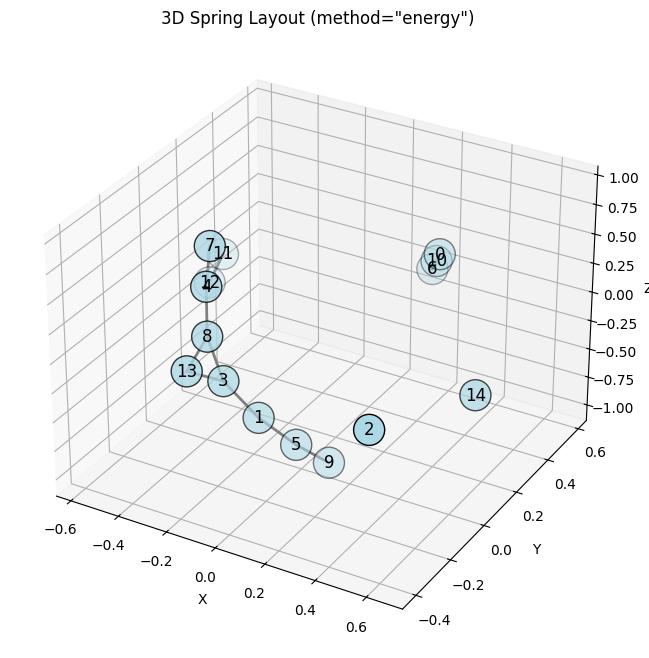

部分节点的3D坐标：
节点0: (0.26, 0.43, 0.33)
节点1: (-0.03, -0.20, -0.42)
节点2: (0.56, -0.40, 0.13)
节点3: (-0.10, -0.28, -0.05)
节点4: (-0.18, -0.26, 0.66)


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 导入3D绘图工具

# 1. 创建示例图（ego图，这里用随机图模拟）
# 如果你有实际的ego图，替换这里即可
ego = nx.erdos_renyi_graph(n=15, p=0.2, seed=25519)  # 15个节点的随机图

# 2. 生成3D弹簧布局，指定method="energy"
pos = nx.spring_layout(
    ego, 
    dim=3,          # 3D维度
    seed=25519,     # 固定随机种子保证复现
    method="energy",# 使用能量最小化方法
    iterations=100, # 增加迭代次数，优化3D分布
    k=0.8           # 3D空间的理想节点间距
)

# 3. 绘制3D布局图
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')  # 创建3D坐标轴

# 提取3D坐标（pos是{节点: (x,y,z)}的字典）
x_coords = [pos[node][0] for node in ego.nodes()]
y_coords = [pos[node][1] for node in ego.nodes()]
z_coords = [pos[node][2] for node in ego.nodes()]

# 绘制节点
ax.scatter(x_coords, y_coords, z_coords, s=500, c='lightblue', edgecolors='black')

# 绘制边
for edge in ego.edges():
    x1, y1, z1 = pos[edge[0]]
    x2, y2, z2 = pos[edge[1]]
    ax.plot([x1, x2], [y1, y2], [z1, z2], 'gray', linewidth=2)

# 标注节点编号
for node in ego.nodes():
    x, y, z = pos[node]
    ax.text(x, y, z, str(node), fontsize=12, ha='center', va='center')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Spring Layout (method="energy")')
plt.show()

# 输出部分节点的3D坐标
print("部分节点的3D坐标：")
for node in list(ego.nodes())[:5]:
    x, y, z = pos[node]
    print(f"节点{node}: ({x:.2f}, {y:.2f}, {z:.2f})")